# 🚀 Otimização de Hiperparâmetros - SVM

Este notebook apresenta um pipeline completo de Machine Learning focado na maximização da acurácia para o dataset Titanic. A estratégia central baseia-se em um **fluxo de refinamento em três etapas**, movendo-se de uma exploração global para uma otimização fina e localizada.

### 🏗️ Estrutura do Pipeline

1. **Pré-processamento Customizado (`PP2`):** Utilização de um pipeline de engenharia de atributos previamente validado e serializado (v1.2), garantindo a consistência dos dados entre treino e teste.
2. **Modelo Base:** Implementação do `RandomForestClassifier` como estimador central, encapsulado em um `Pipeline` do Scikit-Learn.
3. **Otimização de Threshold:** Diferente da predição padrão (0.5), o código implementa uma busca exaustiva pelo **limiar de decisão ideal**, ajustando a sensibilidade do modelo para maximizar a acurácia final.

### 🔍 Estratégia de Busca (O Funil)

O processo de busca de hiperparâmetros foi dividido em três níveis de granularidade:

* **Fase 1: Busca Exploratória (`RandomizedSearchCV`):** Exploração de um espaço amostral amplo para identificar as regiões de alta performance e os parâmetros mais influentes.
* **Fase 2: Refinamento Estruturado (`RandomizedSearchCV`):** Estreitamento dos intervalos de busca com base nos resultados da Fase 1, aumentando a densidade de tentativas em áreas promissoras.
* **Fase 3: Otimização Bayesiana (`BayesSearchCV`):** Refinamento final utilizando inteligência estatística. Diferente da busca aleatória, esta etapa aprende com os resultados anteriores para convergir para o ótimo global com maior precisão.

### 📊 Avaliação e Robustez

A decisão final não se baseia apenas em um único score, mas em uma bateria de testes rigorosos:

* **Métricas Cruzadas:** Comparação de `ROC-AUC` e `Accuracy` via Cross-Validation (10-folds).
* **Estabilidade Estatística:** Aplicação do **T-Test Pareado** para confirmar se a diferença de performance entre os modelos é estatisticamente significante ou fruto do acaso.
* **Generalização:** Teste final em dados inéditos (`X_test`) comparando a acurácia padrão (0.5) contra a acurácia com threshold otimizado.

### 💾 Entrega

O código final automatiza o salvamento dos três melhores estimadores em formato `.joblib`, permitindo a reprodutibilidade imediata e o deploy dos modelos otimizados.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import time

# SVM
from sklearn.svm import SVC

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin, clone

from scipy.stats import loguniform, randint, ttest_rel, uniform



#hiperparamentros search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import randint, uniform


# Importações locais 
from setup_notebook import setup_path
setup_path()
from src.model_utils import *
from src.preprocess_utils_tic import preprocessador_titanic
from src.plot_metrica_class import *

# Configurações e Inicialização
warnings.filterwarnings("ignore")
print(f"\n# Processo iniciado em: {time.strftime('%H:%M:%S')}")


# Processo iniciado em: 11:52:46


## 1. Load Data & Pipeline

In [2]:
BASE = Path.cwd().parent

PP2 = joblib.load(BASE/'src'/'preprocess_Titanic_v1.2.joblib')['preprocessador']

DATA_DIR = BASE/"data"/"raw"
X_train = pd.read_csv(DATA_DIR/"X_train_raw.csv")
X_test  = pd.read_csv(DATA_DIR/"X_test_raw.csv")
y_train = pd.read_csv(DATA_DIR/"y_train_raw.csv").values.ravel()
y_test  = pd.read_csv(DATA_DIR/"y_test_raw.csv").values.ravel()
print(f"\n# Processo iniciado em: {time.strftime('%H:%M:%S')}")


# Processo iniciado em: 11:52:47


## 2. Load Data & Pipeline

In [3]:
# Baseline
model_base = SVC(kernel='rbf',random_state=42, probability=True)  # kernel não fixado!

pipe_base = Pipeline([('preprocess', PP2),
                      ('scaler', StandardScaler()),
                      ('model', model_base)])

pipe_base.fit(X_train, y_train)
y_probs0 = pipe_base.predict_proba(X_test)[:, 1]

best_th0 , max_acc0=best_threshold(pipe_base,X_test,y_test)


print(f"{'='*70}")
print(f"🎯 Melhor Threshold: {best_th0:.3f}")
print(f"📈 Melhor Acurácia de Teste: {max_acc0:.4f}")

baseline_scores = cross_val_score(pipe_base, X_train, y_train, cv=10)
print(f"Baseline: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")
print(f"Average CV Accuracy: {np.mean(baseline_scores)*100:.2f}%") 

mtd_scoring='accuracy'
#accuracy

# linear=================================================================
#🎯 Melhor Threshold: 0.560
#📈 Melhor Acurácia de Teste: 0.8284
#Baseline: 0.8154 ± 0.0591
#Average CV Accuracy: 81.54%
# poly===================================================================
# 🎯 Melhor Threshold: 0.480
# 📈 Melhor Acurácia de Teste: 0.8060
# Baseline: 0.8171 ± 0.0418
# Average CV Accuracy: 81.71%
# rbf===================================================================
# 🎯 Melhor Threshold: 0.370
# 📈 Melhor Acurácia de Teste: 0.8209
# Baseline: 0.8379 ± 0.0629
# Average CV Accuracy: 83.79%

🎯 Melhor Threshold: 0.370
📈 Melhor Acurácia de Teste: 0.8209
Baseline: 0.8379 ± 0.0629
Average CV Accuracy: 83.79%


## 3.Buscas por hiperparamentros
### 3.1.Random Search (Exploratória)

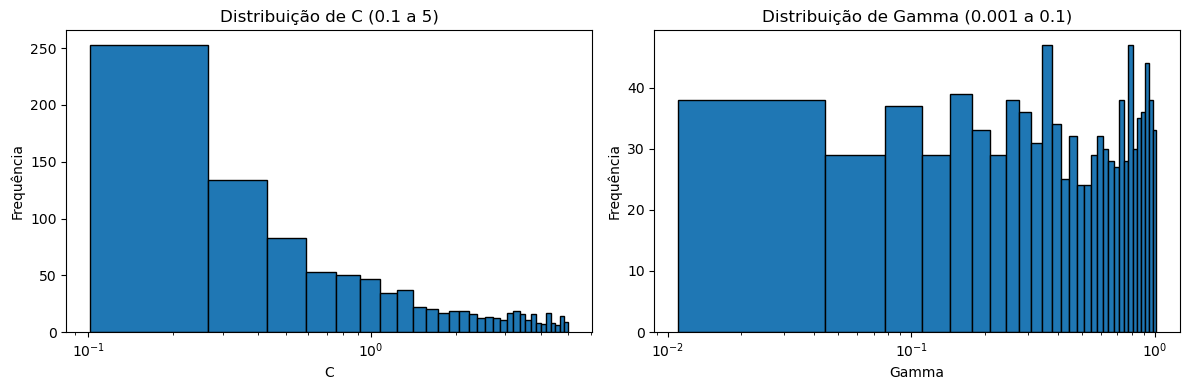

C - min: 0.102, mediana: 0.685, max: 4.997
Gamma - min: 0.0111, mediana: 0.5082, max: 1.0093


In [46]:
C_samples = loguniform(0.1, 5).rvs(size=1000)
gamma_samples = uniform(1e-2, 1).rvs(size=1000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma para C
axes[0].hist(C_samples, bins=30, edgecolor='black')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de C (0.1 a 5)')
axes[0].set_xscale('log')  # Escala log para ver distribuição uniforme

# Histograma para gamma
axes[1].hist(gamma_samples, bins=30, edgecolor='black')
axes[1].set_xlabel('Gamma')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição de Gamma (0.001 a 0.1)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# Estatísticas
print("C - min: {:.3f}, mediana: {:.3f}, max: {:.3f}".format(
    C_samples.min(), np.median(C_samples), C_samples.max()))
print("Gamma - min: {:.4f}, mediana: {:.4f}, max: {:.4f}".format(
    gamma_samples.min(), np.median(gamma_samples), gamma_samples.max()))

In [49]:
print(f"# Processo iniciado em: {time.strftime('%H:%M:%S')}")
param_dist_1 = {
    'model__gamma':  uniform(0.01, 0.08), 
    'model__C': loguniform(0.1,8),              
    'model__class_weight': [None]
}


n_it=100
search_1 =  RandomizedSearchCV(
    pipe_base,
    param_dist_1,
    n_iter=n_it, 
    cv=10,
    scoring=mtd_scoring,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start = time.time()
search_1.fit(X_train, y_train)
end = time.time()

best_1 = search_1.best_estimator_


# 2. Testar vários thresholds
y_probs1 = best_1.predict_proba(X_test)[:, 1]

best_th1 , max_acc1=best_threshold(best_1 ,X_test,y_test)
print("📌 Melhores Parâmetros:")
print(search_1.best_params_)
print(f"\n{'='*70}")
print(f"🎯 Melhor Threshold: {best_th1:.3f}")
print(f"📈 Melhor Acurácia de Teste: {max_acc1:.4f}")
print(f"{'='*70}")

#ACCURACY
scores1 = cross_val_score(best_1, X_train, y_train, cv=10)
print(f"{'='*70}")
print(f"Optimized: {scores1.mean():.4f} ± {scores1.std():.4f}")
print(f"Average CV Accuracy: {np.mean(scores1)*100:.2f}%")
print(f"Tempo total: {end-start:.2f} segundos")
print(f"Tempo por iteração: {(end-start)/50:.2f} segundos")
print("\n#Processo finalizado em:", time.strftime("%H:%M:%S"))

# Processo iniciado em: 12:16:12
📌 Melhores Parâmetros:
{'model__C': 2.2673315313319824, 'model__class_weight': None, 'model__gamma': 0.03278723955019741}

🎯 Melhor Threshold: 0.320
📈 Melhor Acurácia de Teste: 0.8172
Optimized: 0.8460 ± 0.0467
Average CV Accuracy: 84.60%
Tempo total: 32.14 segundos
Tempo por iteração: 0.64 segundos

#Processo finalizado em: 12:16:45


In [75]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

print(f"# Processo iniciado em: {time.strftime('%H:%M:%S')}")

# 1. DEFINIR GRID DE PARÂMETROS
# ---------------------------------
# Para C: valores log-uniformes entre 0.1 e 8

C_values = np.logspace(np.log10(0.1), np.log10(8), num=50)

# Para gamma: valores uniformes entre 0.01 e 0.09 (0.01 + 0.08 = 0.09)
gamma_values = np.linspace(0.01, 0.09, num=50)

param_grid = {
    'model__gamma': gamma_values,
    'model__C': C_values,
    'model__class_weight': [None]
}

print(f"\n📊 Grid de parâmetros:")
print(f"   C: {len(C_values)} valores (de {C_values[0]:.3f} a {C_values[-1]:.3f})")
print(f"   Gamma: {len(gamma_values)} valores (de {gamma_values[0]:.3f} a {gamma_values[-1]:.3f})")
print(f"   Total combinações: {len(C_values) * len(gamma_values)}")

# 2. EXECUTAR GRIDSEARCH
# ---------------------------------
grid_search = GridSearchCV(
    pipe_base,
    param_grid,
    cv=10,
    scoring=mtd_scoring,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"# Processo Finalizado em: {time.strftime('%H:%M:%S')}")


# Processo iniciado em: 13:03:37

📊 Grid de parâmetros:
   C: 50 valores (de 0.100 a 8.000)
   Gamma: 50 valores (de 0.010 a 0.090)
   Total combinações: 2500
Fitting 10 folds for each of 2500 candidates, totalling 25000 fits
# Processo Finalizado em: 13:18:58


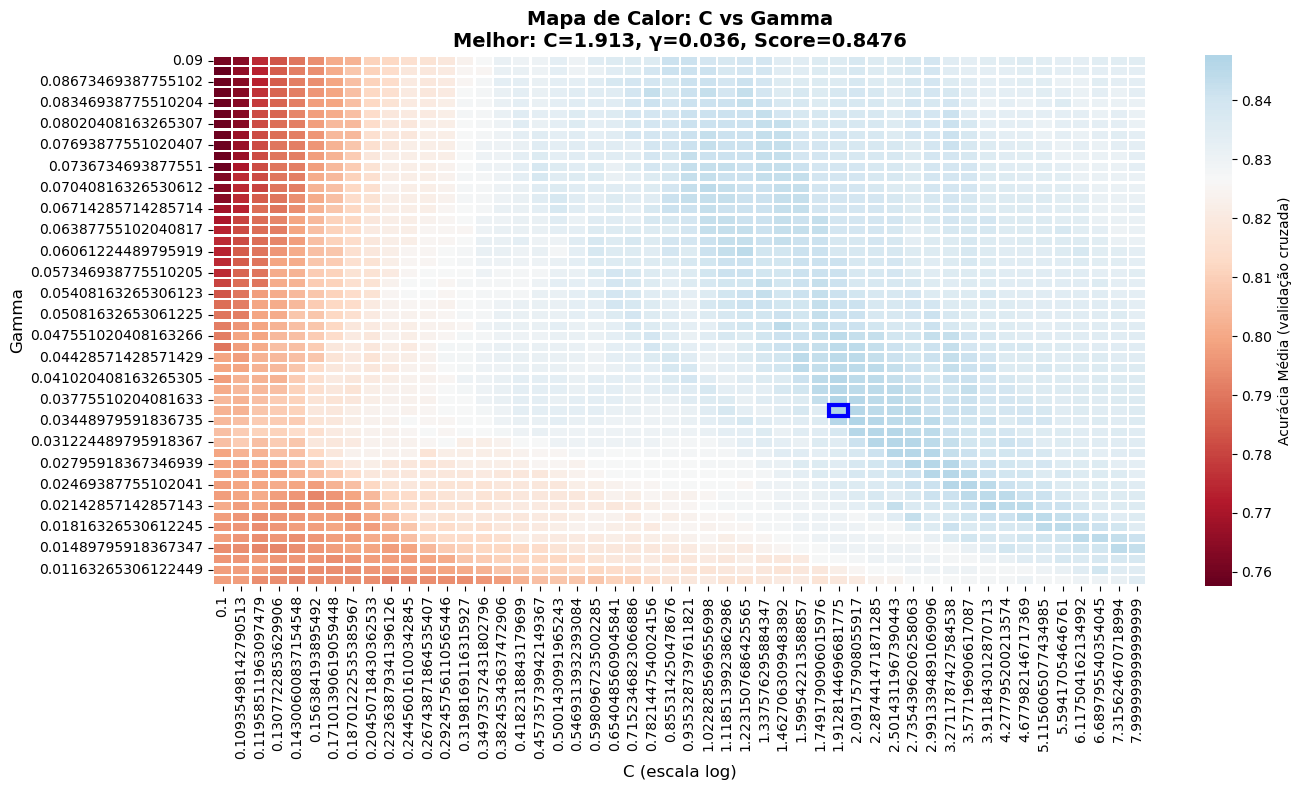

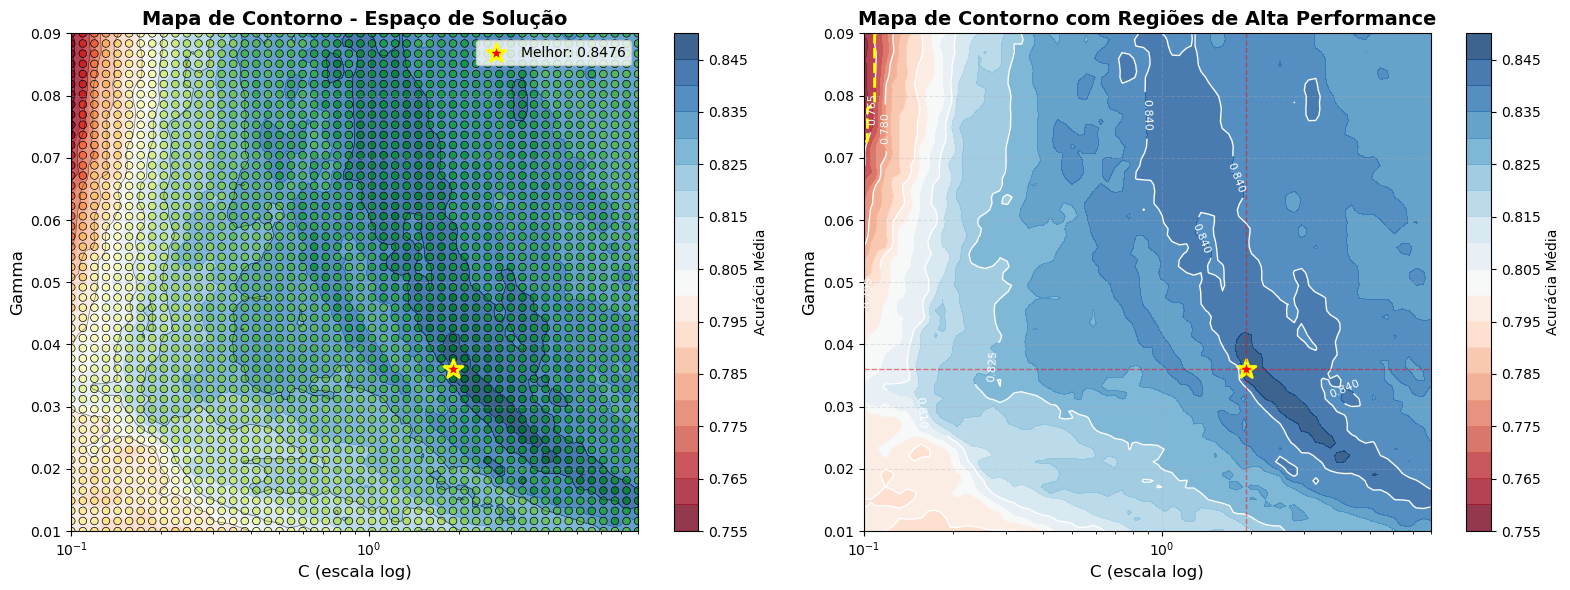

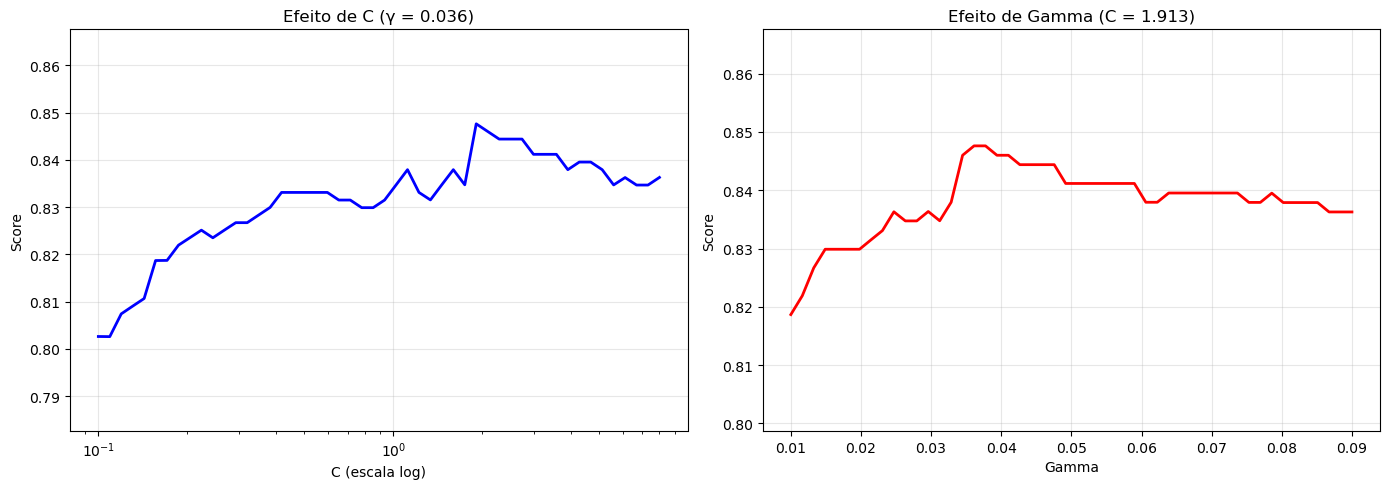


📈 ANÁLISE DOS RESULTADOS

✅ MELHOR RESULTADO:
   C = 1.9128
   Gamma = 0.0361
   Score médio = 0.8476
   Desvio padrão = 0.0478

📊 COMPORTAMENTO POR FAIXA DE C:
   C ∈ [0.1, 0.5]:
      Média = 0.8114
      Máximo = 0.8379
   C ∈ [0.5, 2.0]:
      Média = 0.8338
      Máximo = 0.8476
   C ∈ [2.0, 8.0]:
      Média = 0.8367
      Máximo = 0.8476

📊 COMPORTAMENTO POR FAIXA DE GAMMA:
   Gamma ∈ [0.01, 0.03]:
      Média = 0.8216
      Máximo = 0.8460
   Gamma ∈ [0.03, 0.06]:
      Média = 0.8299
      Máximo = 0.8476
   Gamma ∈ [0.06, 0.09]:
      Média = 0.8271
      Máximo = 0.8444

🏆 TOP 10 COMBINAÇÕES:
   C=1.913, γ=0.036 → 0.8476 (±0.0478)
   C=1.913, γ=0.038 → 0.8476 (±0.0478)
   C=2.092, γ=0.034 → 0.8476 (±0.0478)
   C=1.913, γ=0.039 → 0.8460 (±0.0467)
   C=1.913, γ=0.041 → 0.8460 (±0.0467)
   C=2.092, γ=0.036 → 0.8460 (±0.0467)
   C=2.092, γ=0.038 → 0.8460 (±0.0467)
   C=2.287, γ=0.033 → 0.8460 (±0.0467)
   C=2.287, γ=0.034 → 0.8460 (±0.0467)
   C=2.501, γ=0.030 → 0.8460 (±0.0467

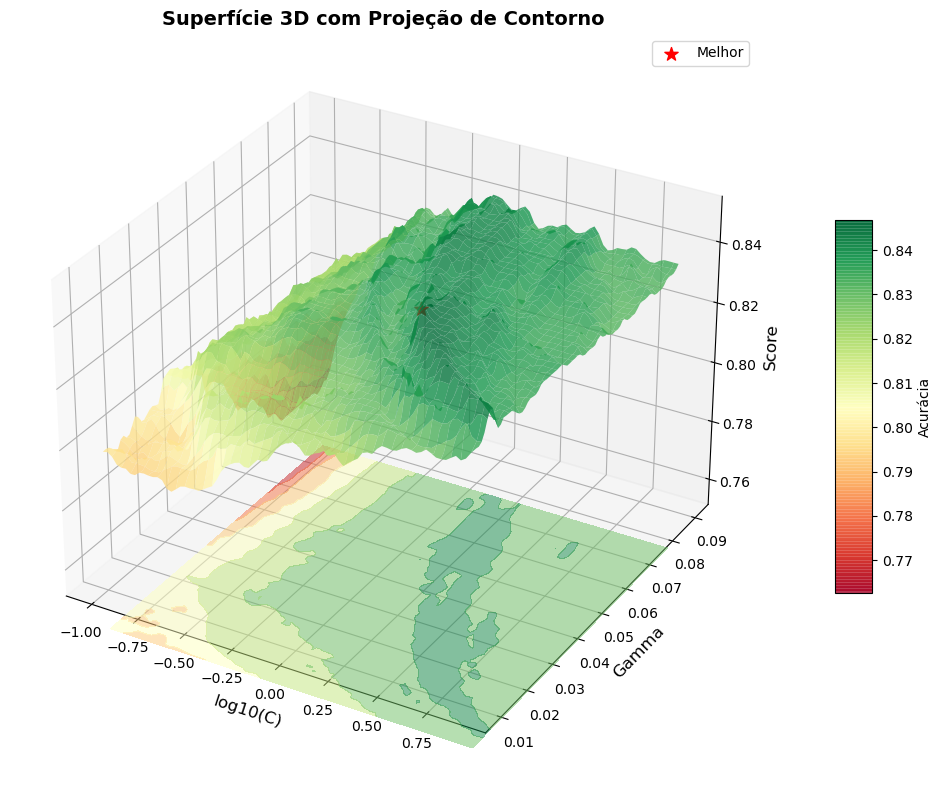


# Processo finalizado em: 13:42:03


In [79]:
# MAPA DE CALOR DOS RESULTADOS
results = pd.DataFrame(grid_search.cv_results_)

# Criar matriz de scores
score_matrix = results.pivot_table(
    values='mean_test_score',
    index='param_model__gamma',
    columns='param_model__C',
    aggfunc='mean')

# Ordenar índices
score_matrix = score_matrix.sort_index(ascending=False)

plt.figure(figsize=(14, 8))

# ax = sns.heatmap(score_matrix, 
#                  annot=True, 
#                  fmt='.3f',
#                  cmap='RdBu',
#                  center=score_matrix.values.mean(),
#                  linewidths=1,
#                  linecolor='white',
#                  cbar_kws={'label': 'Acurácia Média (validação cruzada)'})

ax = sns.heatmap(score_matrix, 
                 cmap='RdBu',
                 center=score_matrix.values.mean(),
                 linewidths=1,
                 linecolor='white',
                 cbar_kws={'label': 'Acurácia Média (validação cruzada)'})

# Destacar o melhor ponto
best_idx = results['mean_test_score'].idxmax()
best_C = results.loc[best_idx, 'param_model__C']
best_gamma = results.loc[best_idx, 'param_model__gamma']
best_score = results.loc[best_idx, 'mean_test_score']

# Encontrar posição no heatmap - CORRIGIDO
gamma_idx = list(score_matrix.index).index(best_gamma)
C_idx = list(score_matrix.columns).index(best_C)

ax.add_patch(plt.Rectangle((C_idx, gamma_idx), 1, 1, 
                           fill=False, edgecolor='blue', lw=3))

plt.title(f'Mapa de Calor: C vs Gamma\nMelhor: C={best_C:.3f}, γ={best_gamma:.3f}, Score={best_score:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('C (escala log)', fontsize=12)
plt.ylabel('Gamma', fontsize=12)

plt.tight_layout()
plt.show()



import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.colors as colors


# 3. PREPARAR DADOS PARA O MAPA DE CONTORNO
C_vals = results['param_model__C'].values
gamma_vals = results['param_model__gamma'].values
scores = results['mean_test_score'].values

# 4. CRIAR GRID FINO PARA INTERPOLAÇÃO
# ---------------------------------
# Criar grid de pontos para interpolação
C_grid = np.logspace(np.log10(0.1), np.log10(8), num=80)  # grid mais fino para C
gamma_grid = np.linspace(0.01, 0.09, num=80)  # grid mais fino para gamma
C_mesh, gamma_mesh = np.meshgrid(C_grid, gamma_grid)

# Interpolar scores para o grid fino
points = np.column_stack([np.log10(C_vals), gamma_vals])  # usar log(C) para interpolação
grid_points = np.column_stack([np.log10(C_mesh.flatten()), gamma_mesh.flatten()])
scores_grid = griddata(points, scores, grid_points, method='cubic')
scores_grid = scores_grid.reshape(C_mesh.shape)

# 5. MAPA DE CONTORNO PRINCIPAL
# ---------------------------------
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Contorno preenchido
ax1 = fig.add_subplot(1, 2, 1)

# Contorno preenchido
contour_filled = ax1.contourf(C_mesh, gamma_mesh, scores_grid, 
                               levels=20, cmap='RdBu', alpha=0.8)

# Contorno com linhas
contour_lines = ax1.contour(C_mesh, gamma_mesh, scores_grid, 
                            levels=10, colors='black', linewidths=0.5, alpha=0.5)

# Pontos do grid original
ax1.scatter(C_vals, gamma_vals, c=scores, s=30, 
           cmap='RdYlGn', edgecolors='black', linewidth=0.5)

# Destacar melhor ponto
best_idx = results['mean_test_score'].idxmax()
best_C = results.loc[best_idx, 'param_model__C']
best_gamma = results.loc[best_idx, 'param_model__gamma']
best_score = results.loc[best_idx, 'mean_test_score']

ax1.scatter(best_C, best_gamma, c='red', s=200, 
           marker='*', edgecolors='yellow', linewidth=2, 
           label=f'Melhor: {best_score:.4f}', zorder=5)

ax1.set_xscale('log')
ax1.set_xlabel('C (escala log)', fontsize=12)
ax1.set_ylabel('Gamma', fontsize=12)
ax1.set_title('Mapa de Contorno - Espaço de Solução', fontsize=14, fontweight='bold')
plt.colorbar(contour_filled, ax=ax1, label='Acurácia Média')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')

# 6. MAPA DE CONTORNO COM ANOTAÇÕES
# ---------------------------------
ax2 = fig.add_subplot(1, 2, 2)

# Contorno preenchido com mapa de cores diferente
contour_filled2 = ax2.contourf(C_mesh, gamma_mesh, scores_grid, 
                                levels=20, cmap='RdBu', alpha=0.8)

# Adicionar labels nos contornos
contour_lines2 = ax2.contour(C_mesh, gamma_mesh, scores_grid, 
                             levels=8, colors='white', linewidths=1)
ax2.clabel(contour_lines2, inline=True, fontsize=8, fmt='%.3f')

# Regiões de interesse
ax2.axhline(y=best_gamma, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(x=best_C, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Áreas de alta performance (>90% do máximo)
threshold = best_score * 0.9
high_perf_mask = scores_grid >= threshold
if high_perf_mask.any():
    ax2.contour(C_mesh, gamma_mesh, high_perf_mask, levels=[0.5], 
                colors='yellow', linewidths=2, linestyles='--', 
                label=f'>90% do máximo')

ax2.scatter(best_C, best_gamma, c='red', s=200, 
           marker='*', edgecolors='yellow', linewidth=2)

ax2.set_xscale('log')
ax2.set_xlabel('C (escala log)', fontsize=12)
ax2.set_ylabel('Gamma', fontsize=12)
ax2.set_title('Mapa de Contorno com Regiões de Alta Performance', fontsize=14, fontweight='bold')
plt.colorbar(contour_filled2, ax=ax2, label='Acurácia Média')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


# 5. GRÁFICO DE LINHAS CORRIGIDO
# ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Efeito de C (fixando gamma no melhor valor)
gamma_fixed = best_gamma
C_effect = results[np.abs(results['param_model__gamma'] - gamma_fixed) < 1e-10].copy()
C_effect = C_effect.sort_values('param_model__C')

# CONVERTER PARA ARRAY NUMPY PARA EVITAR ERRO DE INDEXAÇÃO
C_values_array = C_effect['param_model__C'].values
scores_array = C_effect['mean_test_score'].values
std_array = C_effect['std_test_score'].values

axes[0].plot(C_values_array, scores_array, '-', linewidth=2, color='blue', markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (escala log)')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Efeito de C (γ = {gamma_fixed:.3f})')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([scores_array.min() - 0.02, scores_array.max() + 0.02])

# Efeito de gamma (fixando C no melhor valor)
C_fixed = best_C
gamma_effect = results[np.abs(results['param_model__C'] - C_fixed) < 1e-10].copy()
gamma_effect = gamma_effect.sort_values('param_model__gamma')

# CONVERTER PARA ARRAY NUMPY
gamma_values_array = gamma_effect['param_model__gamma'].values
scores_gamma_array = gamma_effect['mean_test_score'].values
std_gamma_array = gamma_effect['std_test_score'].values

axes[1].plot(gamma_values_array, scores_gamma_array, '-', linewidth=2, color='red', markersize=8)

axes[1].set_xlabel('Gamma')
axes[1].set_ylabel('Score')
axes[1].set_title(f'Efeito de Gamma (C = {C_fixed:.3f})')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([scores_gamma_array.min() - 0.02, scores_gamma_array.max() + 0.02])

plt.tight_layout()
plt.show()


# 6. ANÁLISE DETALHADA
# ---------------------------------
print("\n" + "="*60)
print("📈 ANÁLISE DOS RESULTADOS")
print("="*60)

# Melhor resultado
print(f"\n✅ MELHOR RESULTADO:")
print(f"   C = {best_C:.4f}")
print(f"   Gamma = {best_gamma:.4f}")
print(f"   Score médio = {best_score:.4f}")
print(f"   Desvio padrão = {results.loc[best_idx, 'std_test_score']:.4f}")

# Análise por faixa de C
print(f"\n📊 COMPORTAMENTO POR FAIXA DE C:")
C_ranges = [(0.1, 0.5), (0.5, 2), (2, 8)]
for c_min, c_max in C_ranges:
    mask = (results['param_model__C'] >= c_min) & (results['param_model__C'] < c_max)
    range_results = results[mask]
    print(f"   C ∈ [{c_min:.1f}, {c_max:.1f}]:")
    print(f"      Média = {range_results['mean_test_score'].mean():.4f}")
    print(f"      Máximo = {range_results['mean_test_score'].max():.4f}")

# Análise por faixa de gamma
print(f"\n📊 COMPORTAMENTO POR FAIXA DE GAMMA:")
gamma_ranges = [(0.01, 0.03), (0.03, 0.06), (0.06, 0.09)]
for g_min, g_max in gamma_ranges:
    mask = (results['param_model__gamma'] >= g_min) & (results['param_model__gamma'] < g_max)
    range_results = results[mask]
    print(f"   Gamma ∈ [{g_min:.2f}, {g_max:.2f}]:")
    print(f"      Média = {range_results['mean_test_score'].mean():.4f}")
    print(f"      Máximo = {range_results['mean_test_score'].max():.4f}")

# Top 10 combinações
print(f"\n🏆 TOP 10 COMBINAÇÕES:")
top10 = results.nlargest(10, 'mean_test_score')[['param_model__C', 'param_model__gamma', 'mean_test_score', 'std_test_score']]
for idx, row in top10.iterrows():
    print(f"   C={row['param_model__C']:.3f}, γ={row['param_model__gamma']:.3f} → {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")






# Criar figura e eixos 3D diretamente
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(projection='3d')

# Plotar superfície
surf = ax.plot_surface(np.log10(C_mesh), gamma_mesh, scores_grid, 
                       cmap='RdYlGn', alpha=0.8, linewidth=0, antialiased=True)

# Projetar contorno na base
contour = ax.contourf(np.log10(C_mesh), gamma_mesh, scores_grid, 
                      zdir='z', offset=scores_grid.min() - 0.02, 
                      cmap='RdYlGn', alpha=0.5)

# Melhor ponto
ax.scatter(np.log10(best_C), best_gamma, best_score, 
          c='red', s=100, marker='*', label='Melhor')

# Configurar rótulos e título
ax.set_xlabel('log10(C)', fontsize=12)
ax.set_ylabel('Gamma', fontsize=12)
ax.set_zlabel('Score', fontsize=12)
ax.set_title('Superfície 3D com Projeção de Contorno', fontsize=14, fontweight='bold')

# Adicionar legenda
ax.legend()

# Adicionar colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Acurácia')

# Ajustar layout
plt.tight_layout()

# Mostrar o gráfico
plt.show()



print(f"\n# Processo finalizado em: {time.strftime('%H:%M:%S')}")

In [114]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

print(f"# Processo iniciado em: {time.strftime('%H:%M:%S')}")

# 1. DEFINIR GRID DE PARÂMETROS
# ---------------------------------
# Para C: valores log-uniformes entre 0.1 e 8

C_values = np.logspace(np.log10(0.8), np.log10(4), num=30)

# Para gamma: valores uniformes entre 0.01 e 0.09 (0.01 + 0.08 = 0.09)
gamma_values = np.linspace(0.01, 0.09, num=30)

param_grid = {
    'model__gamma': gamma_values,
    'model__C': C_values,
    'model__class_weight': [None]
}

print(f"\n📊 Grid de parâmetros:")
print(f"   C: {len(C_values)} valores (de {C_values[0]:.3f} a {C_values[-1]:.3f})")
print(f"   Gamma: {len(gamma_values)} valores (de {gamma_values[0]:.3f} a {gamma_values[-1]:.3f})")
print(f"   Total combinações: {len(C_values) * len(gamma_values)}")

# 2. EXECUTAR GRIDSEARCH
# ---------------------------------
grid_search = GridSearchCV(
    pipe_base,
    param_grid,
    cv=10,
    scoring=mtd_scoring,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"# Processo Finalizado em: {time.strftime('%H:%M:%S')}")



# Processo iniciado em: 14:21:14

📊 Grid de parâmetros:
   C: 30 valores (de 0.800 a 4.000)
   Gamma: 30 valores (de 0.010 a 0.090)
   Total combinações: 900
Fitting 10 folds for each of 900 candidates, totalling 9000 fits
# Processo Finalizado em: 14:26:36


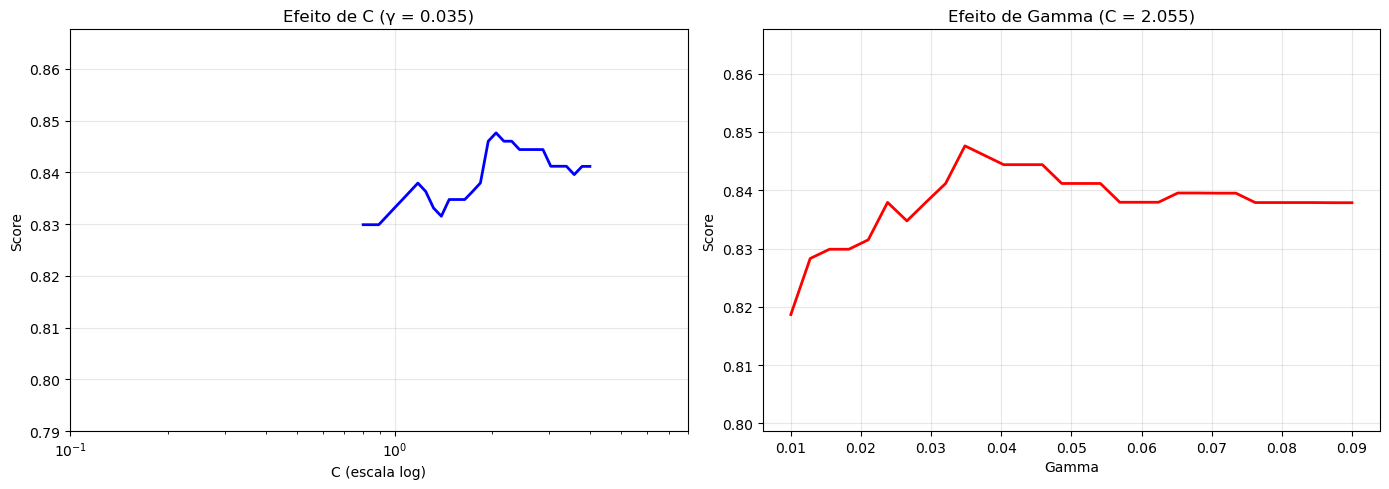


# Processo finalizado em: 14:39:51

📈 ANÁLISE DOS RESULTADOS

✅ MELHOR RESULTADO:
   C = 2.0551
   Gamma = 0.0348
   Score médio = 0.8476
   Desvio padrão = 0.0478

📊 COMPORTAMENTO POR FAIXA DE C:
   C ∈ [0.1, 0.5]:
      Média = nan
      Máximo = nan
   C ∈ [0.5, 2.0]:
      Média = 0.8354
      Máximo = 0.8460
   C ∈ [2.0, 8.0]:
      Média = 0.8379
      Máximo = 0.8476

📊 COMPORTAMENTO POR FAIXA DE GAMMA:
   Gamma ∈ [0.01, 0.03]:
      Média = 0.8300
      Máximo = 0.8460
   Gamma ∈ [0.03, 0.06]:
      Média = 0.8386
      Máximo = 0.8476
   Gamma ∈ [0.06, 0.09]:
      Média = 0.8392
      Máximo = 0.8444

🏆 TOP 10 COMBINAÇÕES:
   C=2.055, γ=0.035 → 0.8476 (±0.0478)
   C=1.839, γ=0.040 → 0.8460 (±0.0467)
   C=1.944, γ=0.038 → 0.8460 (±0.0467)
   C=1.944, γ=0.040 → 0.8460 (±0.0467)
   C=2.055, γ=0.038 → 0.8460 (±0.0467)
   C=2.172, γ=0.035 → 0.8460 (±0.0467)
   C=2.296, γ=0.032 → 0.8460 (±0.0467)
   C=2.296, γ=0.035 → 0.8460 (±0.0467)
   C=2.427, γ=0.032 → 0.8460 (±0.0467)
   C=2.

In [115]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.colors as colors
# MAPA DE CALOR DOS RESULTADOS
results = pd.DataFrame(grid_search.cv_results_)

# Criar matriz de scores
score_matrix = results.pivot_table(
    values='mean_test_score',
    index='param_model__gamma',
    columns='param_model__C',
    aggfunc='mean')

# Ordenar índices
score_matrix = score_matrix.sort_index(ascending=False)

# Destacar o melhor ponto
best_idx = results['mean_test_score'].idxmax()
best_C = results.loc[best_idx, 'param_model__C']
best_gamma = results.loc[best_idx, 'param_model__gamma']
best_score = results.loc[best_idx, 'mean_test_score']

# Encontrar posição no heatmap - CORRIGIDO
gamma_idx = list(score_matrix.index).index(best_gamma)
C_idx = list(score_matrix.columns).index(best_C)


# 3. PREPARAR DADOS PARA O MAPA DE CONTORNO
C_vals = results['param_model__C'].values
gamma_vals = results['param_model__gamma'].values
scores = results['mean_test_score'].values

# 4. CRIAR GRID FINO PARA INTERPOLAÇÃO
# ---------------------------------
# Criar grid de pontos para interpolação
C_grid = np.logspace(np.log10(0.1), np.log10(8), num=80)  # grid mais fino para C
gamma_grid = np.linspace(0.01, 0.09, num=80)  # grid mais fino para gamma
C_mesh, gamma_mesh = np.meshgrid(C_grid, gamma_grid)

# Interpolar scores para o grid fino
points = np.column_stack([np.log10(C_vals), gamma_vals])  # usar log(C) para interpolação
grid_points = np.column_stack([np.log10(C_mesh.flatten()), gamma_mesh.flatten()])
scores_grid = griddata(points, scores, grid_points, method='cubic')
scores_grid = scores_grid.reshape(C_mesh.shape)

# 5. MAPA DE CONTORNO PRINCIPAL
# ---------------------------------


# Destacar melhor ponto
best_idx = results['mean_test_score'].idxmax()
best_C = results.loc[best_idx, 'param_model__C']
best_gamma = results.loc[best_idx, 'param_model__gamma']
best_score = results.loc[best_idx, 'mean_test_score']



# 5. GRÁFICO DE LINHAS CORRIGIDO
# ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Efeito de C (fixando gamma no melhor valor)
gamma_fixed = best_gamma
C_effect = results[np.abs(results['param_model__gamma'] - gamma_fixed) < 1e-10].copy()
C_effect = C_effect.sort_values('param_model__C')

# CONVERTER PARA ARRAY NUMPY PARA EVITAR ERRO DE INDEXAÇÃO
C_values_array = C_effect['param_model__C'].values
scores_array = C_effect['mean_test_score'].values
std_array = C_effect['std_test_score'].values

axes[0].plot(C_values_array, scores_array, '-', linewidth=2, color='blue', markersize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (escala log)')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Efeito de C (γ = {gamma_fixed:.3f})')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.79, scores_array.max() + 0.02])
axes[0].set_xlim([0.1,8])

# Efeito de gamma (fixando C no melhor valor)
C_fixed = best_C
gamma_effect = results[np.abs(results['param_model__C'] - C_fixed) < 1e-10].copy()
gamma_effect = gamma_effect.sort_values('param_model__gamma')

# CONVERTER PARA ARRAY NUMPY
gamma_values_array = gamma_effect['param_model__gamma'].values
scores_gamma_array = gamma_effect['mean_test_score'].values
std_gamma_array = gamma_effect['std_test_score'].values

axes[1].plot(gamma_values_array, scores_gamma_array, '-', linewidth=2, color='red', markersize=8)

axes[1].set_xlabel('Gamma')
axes[1].set_ylabel('Score')
axes[1].set_title(f'Efeito de Gamma (C = {C_fixed:.3f})')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([scores_gamma_array.min() - 0.02, scores_gamma_array.max() + 0.02])

plt.tight_layout()
plt.show()

print(f"\n# Processo finalizado em: {time.strftime('%H:%M:%S')}")

# 6. ANÁLISE DETALHADA
# ---------------------------------
print("\n" + "="*60)
print("📈 ANÁLISE DOS RESULTADOS")
print("="*60)

# Melhor resultado
print(f"\n✅ MELHOR RESULTADO:")
print(f"   C = {best_C:.4f}")
print(f"   Gamma = {best_gamma:.4f}")
print(f"   Score médio = {best_score:.4f}")
print(f"   Desvio padrão = {results.loc[best_idx, 'std_test_score']:.4f}")

# Análise por faixa de C
print(f"\n📊 COMPORTAMENTO POR FAIXA DE C:")
C_ranges = [(0.1, 0.5), (0.5, 2), (2, 8)]
for c_min, c_max in C_ranges:
    mask = (results['param_model__C'] >= c_min) & (results['param_model__C'] < c_max)
    range_results = results[mask]
    print(f"   C ∈ [{c_min:.1f}, {c_max:.1f}]:")
    print(f"      Média = {range_results['mean_test_score'].mean():.4f}")
    print(f"      Máximo = {range_results['mean_test_score'].max():.4f}")

# Análise por faixa de gamma
print(f"\n📊 COMPORTAMENTO POR FAIXA DE GAMMA:")
gamma_ranges = [(0.01, 0.03), (0.03, 0.06), (0.06, 0.09)]
for g_min, g_max in gamma_ranges:
    mask = (results['param_model__gamma'] >= g_min) & (results['param_model__gamma'] < g_max)
    range_results = results[mask]
    print(f"   Gamma ∈ [{g_min:.2f}, {g_max:.2f}]:")
    print(f"      Média = {range_results['mean_test_score'].mean():.4f}")
    print(f"      Máximo = {range_results['mean_test_score'].max():.4f}")

# Top 10 combinações
print(f"\n🏆 TOP 10 COMBINAÇÕES:")
top10 = results.nlargest(10, 'mean_test_score')[['param_model__C', 'param_model__gamma', 'mean_test_score', 'std_test_score']]
for idx, row in top10.iterrows():
    print(f"   C={row['param_model__C']:.3f}, γ={row['param_model__gamma']:.3f} → {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")


In [102]:
scores_gamma_array.min()

0.8202440033085194

### 3.2 Random Search Refinado

In [77]:
# break
# param_dist_2 = {
#     'model__n_estimators': randint(200, 350), 
#     'model__max_depth': [None,1,4,6,8,9,10,11,12],
#     'model__min_samples_split': randint(5,15),
#     'model__min_samples_leaf': randint(1, 4),
#     'model__max_features': ['sqrt',None],
#     'model__criterion': ['gini','entropy'],
#     'model__bootstrap': [False,True],
#     'model__max_leaf_nodes': [None, 20, 50, 100], 
#     'model__min_weight_fraction_leaf': [0.0, 0.1, 0.2] 

# }

# search_2 = RandomizedSearchCV(
#     pipe_base, param_dist_2,
#     n_iter=80, cv=10,
#     scoring=mtd_scoring,
#     random_state=42, n_jobs=-1, verbose=1

# )
# start = time.time()
# search_2.fit(X_train, y_train)
# end = time.time()

# best_2 = search_2.best_estimator_
# # 2. Testar vários thresholds
# y_probs2 = best_2.predict_proba(X_test)[:, 1]
# thresholds = np.linspace(0.3, 0.7, 41)
# best_threshold2 = 0.5
# max_acc = 0

# for t in thresholds:
#     acc = accuracy_score(y_test, y_probs2 > t)
#     if acc > max_acc:
#         max_acc = acc
#         best_threshold2 = t
# print(f"{'='*70}")
# print(f"🎯 Melhor Threshold: {best_threshold2:.3f}")
# print(f"📈 Melhor Acurácia de Teste: {max_acc:.4f}")
# print(f"{'='*70}")

# #ACCURACY
# scores2 = cross_val_score(best_2, X_train, y_train, cv=10)
# print(f"{'='*70}")
# print(f"Optimized: {scores2.mean():.4f} ± {scores2.std():.4f}")
# print(f"Average CV Accuracy: {np.mean(scores2)*100:.2f}%")
# print(f"Tempo total: {end-start:.2f} segundos")
# print(f"Tempo por iteração: {(end-start)/80:.2f} segundos")
# print("📌 Melhores Parâmetros:")
# print(search_2.best_params_)
# print("\n#Processo finalizado em:", time.strftime("%H:%M:%S"))

### 3.3 Bayesian Optimization (Optuna / skopt)

In [ ]:
# ##  Definição do Espaço Bayesiano
# from skopt import BayesSearchCV
# from skopt.space import Integer, Real, Categorical

# param_dist_3 = {
#     'model__n_estimators': Integer(250, 400),          # 312 ± 50
#     'model__max_depth': Integer(8, 15),                # 11 ± 3
#     'model__min_samples_split': Integer(8, 16),        # 12 ± 4
#     'model__min_samples_leaf': Integer(1, 4),          # 2 ± 2
#     'model__max_features': Categorical(['sqrt', None]),
#     'model__criterion': Categorical(['gini', 'entropy']),
#     'model__bootstrap': Categorical([True]),           # Confirmado como melhor
#     'model__max_leaf_nodes': Integer(30, 100),         # 50 ± 20
#     'model__min_weight_fraction_leaf': Real(0.0, 0.1)  # 0.0 até 0.1
# }

# #Configuração do BayesSearch
# bayes_search = BayesSearchCV(
#     estimator=pipe_base,
#     search_spaces=param_dist_3,
#     n_iter=60,
#     cv=10,
#     scoring=mtd_scoring,
#     random_state=42,
#     n_jobs=-1,
# verbose=0)

# start = time.time()
# ## Execução
# print("🔍 Iniciando Bayesian Optimization...")
# bayes_search.fit(X_train, y_train)
# end = time.time()


# best_3 = bayes_search.best_estimator_
# # 2. Testar vários thresholds
# y_probs3 = best_3.predict_proba(X_test)[:, 1]
# thresholds = np.linspace(0.3, 0.7, 41)
# best_threshold3 = 0.5
# max_acc = 0

# for t in thresholds:
#     acc = accuracy_score(y_test, y_probs3 > t)
#     if acc > max_acc:
#         max_acc = acc
#         best_threshold3 = t
# print(f"{'='*70}")
# print(f"🎯 Melhor Threshold: {best_threshold3:.3f}")
# print(f"📈 Melhor Acurácia de Teste: {max_acc:.4f}")
# print(f"{'='*70}")

# #ACCURACY
# scores3 = cross_val_score(best_3, X_train, y_train, cv=10)
# print(f"{'='*70}")
# print(f"Optimized: {scores3.mean():.4f} ± {scores3.std():.4f}")
# print(f"Average CV Accuracy: {np.mean(scores2)*100:.2f}%")
# print(f"Tempo total: {end-start:.2f} segundos")
# print(f"Tempo por iteração: {(end-start)/60:.2f} segundos")
# print("📌 Melhores Parâmetros:")
# print(bayes_search.best_params_)
# print("\n#Processo finalizado em:", time.strftime("%H:%M:%S"))

## 4. Comparação Estatística

In [ ]:
# Calcula os scores de validação cruzada para cada modelo(roc_auc)
s1 = cross_val_score(best_1, X_train, y_train, cv=10,scoring='roc_auc')
s2 = cross_val_score(best_2, X_train, y_train, cv=10,scoring='roc_auc')
s3 = cross_val_score(best_3, X_train, y_train, cv=10,scoring='roc_auc')

# Calcula os scores de validação cruzada para cada modelo(acc)
s1_acc = cross_val_score(best_1, X_train, y_train, cv=10)
s2_acc= cross_val_score(best_2, X_train, y_train, cv=10)
s3_acc = cross_val_score(best_3, X_train, y_train, cv=10)

best_1.fit(X_train, y_train)
best_2.fit(X_train, y_train)
best_3.fit(X_train, y_train)

score1 = best_1.score(X_test, y_test)
score2 = best_2.score(X_test, y_test)
score3 = best_3.score(X_test, y_test)

y_prob1 = best_1.predict_proba(X_test)[:, 1]
y_prob2 = best_2.predict_proba(X_test)[:, 1]
y_prob3 = best_3.predict_proba(X_test)[:, 1]



# 1. Preparação dos Dados de Performance
models_list = [
    ('Modelo 1 (Randon)', best_1, s1, s1_acc, y_prob1, best_threshold1),
    ('Modelo 2 (Refine)', best_2, s2, s2_acc, y_prob2, best_threshold2),
    ('Modelo 3 ( Bayes )',  best_3, s3, s3_acc, y_prob3, best_threshold3)
]

print(f"{'='*80}")
print(f"{'RELATÓRIO DE DESEMPENHO E ESTABILIDADE ESTATÍSTICA':^80}")
print(f"{'='*80}")

# Tabela comparativa de métricas
results_data = []
for name, model, s_roc, s_acc, probs, thresh in models_list:
    test_roc = roc_auc_score(y_test, probs)
    test_acc_std = accuracy_score(y_test, probs > 0.5)
    test_acc_opt = accuracy_score(y_test, probs > thresh)
    
    results_data.append({
        'Modelo': name,
        'CV ROC-AUC': f"{s_roc.mean():.4f} ± {s_roc.std():.2f}",
        'CV ACC': f"{s_acc.mean():.4f} ± {s_acc.std():.2f}",
        'Test ROC-AUC': f"{test_roc:.4f}",
        'Test ACC (0.5)': f"{test_acc_std:.4f}",
        'Best Thresh': f"{thresh:.3f}",
        'Test ACC (Opt)': f"{test_acc_opt:.4f}"
    })

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

print(f"\n{'='*80}")
print(f"{'ANÁLISE DE SIGNIFICÂNCIA ESTATÍSTICA (T-TEST PAREADO)':^80}")
print(f"{'='*80}")

# Função para imprimir p-value formatado
def check_sig(p): return "SIM" if p < 0.05 else "NÃO"

t12, p12 = ttest_rel(s1, s2)
t23, p23 = ttest_rel(s2, s3)
t13, p13 = ttest_rel(s1, s3)

print(f"M1 vs M2: p-value = {p12:.4f} | Diferença Significativa? {check_sig(p12)}")
print(f"M2 vs M3: p-value = {p23:.4f} | Diferença Significativa? {check_sig(p23)}")
print(f"M1 vs M3: p-value = {p13:.4f} | Diferença Significativa? {check_sig(p13)}")

print(f"\n{'='*80}")
print(f"{'CONCLUSÃO TÉCNICA':^80}")
print(f"{'='*80}")

best_idx = df_results['Test ROC-AUC'].astype(float).idxmax()
vencedor = df_results.iloc[best_idx]['Modelo']

print(f"1. O modelo vencedor em generalização (Test ROC-AUC) é o: {vencedor}")
print("\n#Processo finalizado em:", time.strftime("%H:%M:%S"))

## 7. Salvando_hiperparametros

In [ ]:
# Salvar Hiperparametros joblib
# apenas parametros
#joblib.dump(bayes_search.best_params_, 'parametros_RF_BAYER_v12.joblib') 
# modelo completo

mtd_scoring
# joblib.dump(search_1.best_estimator_, 'modelo_RF_final_randsearch.'+mtd_scoring+'_v12.joblib')
# joblib.dump(search_2.best_estimator_, 'modelo_RF_final_refine.'+mtd_scoring+'_v12.joblib')
# joblib.dump(bayes_search.best_estimator_, 'modelo_RF_final.'+mtd_scoring+'_bayes_v12.joblib')